**Parkinsons disease using voice biomarkers**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Load the dataset

In [ ]:
data = pd.read_csv("/content/Parkinsson disease.csv")

print(data.head())
print(data.shape)

             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.0654

3. Data Preprocessing

In [ ]:
#Remove non-numeric column if present (e.g., name column).
data = data.select_dtypes(include=['number'])

In [ ]:
#Separate features and target.
X = data.drop('status', axis=1)
y = data['status']

4. Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

5. Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Random Forest Implementation

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9487179487179487


Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf', C=10)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9487179487179487


Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8974358974358975


Deep Learning Model (Neural Network)

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7177 - loss: 0.6054 - val_accuracy: 0.6875 - val_loss: 0.5141
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7984 - loss: 0.5032 - val_accuracy: 0.7188 - val_loss: 0.4505
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8145 - loss: 0.4435 - val_accuracy: 0.7188 - val_loss: 0.4208
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8145 - loss: 0.3986 - val_accuracy: 0.7812 - val_loss: 0.3947
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8468 - loss: 0.3650 - val_accuracy: 0.7812 - val_loss: 0.3768
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8548 - loss: 0.3402 - val_accuracy: 0.7812 - val_loss: 0.3609
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.8629 - loss: 0.3180 - val_accuracy: 0.7812 - val_loss: 0.3478
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8790 - loss: 0.2995 - val_accuracy: 0.7812 - val_loss: 0.3364


In [ ]:
print("\nAccuracy Comparison")

print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)


Accuracy Comparison
Random Forest: 0.9487179487179487
SVM: 0.9487179487179487
Logistic Regression: 0.8974358974358975
Deep Learning: 0.9230769276618958


Visualization

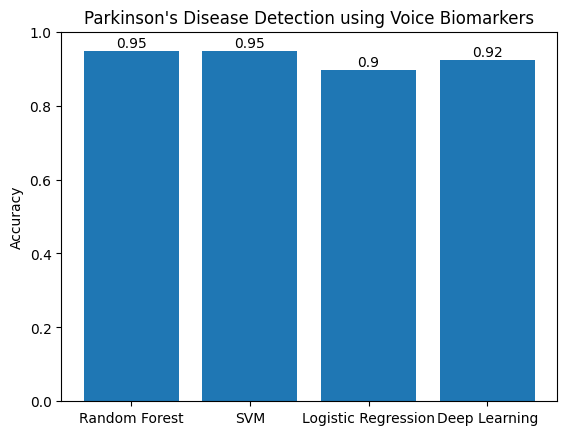

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']

accuracy = [rf_accuracy, svm_accuracy, lr_accuracy, dl_accuracy]

plt.bar(models, accuracy)

plt.title("Parkinson's Disease Detection using Voice Biomarkers")

plt.ylabel("Accuracy")

plt.ylim(0,1)

for i,v in enumerate(accuracy):
    plt.text(i, v+0.01, str(round(v,2)), ha='center')

plt.show()

**Parkinsons disease using Hand tremor**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Load dataset

In [ ]:
import pandas as pd
data = pd.read_csv("/content/Meander_HandPD.csv")
print(data.head())
print(data.shape)
print(data.info())

   _ID_EXAM  IMAGE_NAME  ID_PATIENT  CLASS_TYPE GENDER RIGH/LEFT-HANDED  AGE  \
0        68  0068-1.jpg           1           1      F                L   28   
1        68  0068-2.jpg           1           1      F                L   28   
2        68  0068-3.jpg           1           1      F                L   28   
3        68  0068-4.jpg           1           1      F                L   28   
4        92  0092-1.jpg           2           1      M                R   37   

           RMS  MAX_BETWEEN_ST_HT  MIN_BETWEEN_ST_HT  STD_DEVIATION_ST_HT  \
0  3176.216064        7098.378906        46569.03516             0.000672   
1  2751.015869        6263.803711        44059.59766             0.000000   
2  3050.623779        6548.623047        40298.10938             0.000026   
3  2594.598877        6989.159180        54217.63281             0.000000   
4  3310.786865        6060.232422        35212.75781             0.000667   

         MRT      MAX_HT    MIN_HT       STD_HT  \
0  21

Data Preprocessing

In [ ]:
#Check missing values
print(data.isnull().sum())

_ID_EXAM                                           0
IMAGE_NAME                                         0
ID_PATIENT                                         0
CLASS_TYPE                                         0
GENDER                                             0
RIGH/LEFT-HANDED                                   0
AGE                                                0
RMS                                                0
MAX_BETWEEN_ST_HT                                  0
MIN_BETWEEN_ST_HT                                  0
STD_DEVIATION_ST_HT                                0
MRT                                                0
MAX_HT                                             0
MIN_HT                                             0
STD_HT                                             0
CHANGES_FROM_NEGATIVE_TO_POSITIVE_BETWEEN_ST_HT    0
dtype: int64


In [ ]:
#Separate features and target
X = data.drop('CLASS_TYPE', axis=1)
y = data['CLASS_TYPE']

Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

Feature Scaling

In [ ]:
scaler = StandardScaler()
# Identify and drop non-numeric and identifier columns
columns_to_drop = ['_ID_EXAM', 'IMAGE_NAME', 'ID_PATIENT', 'GENDER', 'RIGH/LEFT-HANDED']
X_train_processed = X_train.drop(columns=columns_to_drop)
X_test_processed = X_test.drop(columns=columns_to_drop)
X_train = scaler.fit_transform(X_train_processed)
X_test = scaler.transform(X_test_processed)

Random Forest Implementation

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:",
accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9324324324324325
              precision    recall  f1-score   support

           1       0.88      0.82      0.85        17
           2       0.95      0.96      0.96        57

    accuracy                           0.93        74
   macro avg       0.91      0.89      0.90        74
weighted avg       0.93      0.93      0.93        74



Support Vector Machine (SVM)

In [ ]:
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
print("SVM Accuracy:",
accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8918918918918919
              precision    recall  f1-score   support

           1       0.85      0.65      0.73        17
           2       0.90      0.96      0.93        57

    accuracy                           0.89        74
   macro avg       0.87      0.81      0.83        74
weighted avg       0.89      0.89      0.89        74



Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
print("Logistic Regression Accuracy:",
accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.9054054054054054
              precision    recall  f1-score   support

           1       0.86      0.71      0.77        17
           2       0.92      0.96      0.94        57

    accuracy                           0.91        74
   macro avg       0.89      0.84      0.86        74
weighted avg       0.90      0.91      0.90        74



Deep Learning Model

In [ ]:
dl_model = Sequential()

dl_model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
dl_model.add(Dense(32, activation='relu'))
dl_model.add(Dense(1, activation='sigmoid'))

dl_model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

dl_model.fit(
X_train, y_train,
epochs=30,
batch_size=16,
validation_split=0.2
)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1532 - loss: -0.0164 - val_accuracy: 0.2203 - val_loss: -0.2540
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1787 - loss: -0.9384 - val_accuracy: 0.2203 - val_loss: -1.0783
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1787 - loss: -2.0011 - val_accuracy: 0.2203 - val_loss: -2.1451
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1787 - loss: -3.4379 - val_accuracy: 0.2203 - val_loss: -3.5431
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1787 - loss: -5.4381 - val_accuracy: 0.2203 - val_loss: -5.4483
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1787 - loss: -8.2038 - val_accuracy: 0.2203 - val_loss: -8.1112
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1787 - loss: -11.9103 - val_accuracy: 0.2203 - val_loss: -11.8408
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1787 - loss: -17.0280 - val_accuracy: 0.2203

In [ ]:
loss, accuracy = dl_model.evaluate(X_test, y_test)
print("Deep Learning Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2297 - loss: -1538.9446
Deep Learning Accuracy: 0.22972972691059113


Model Comparison Graph

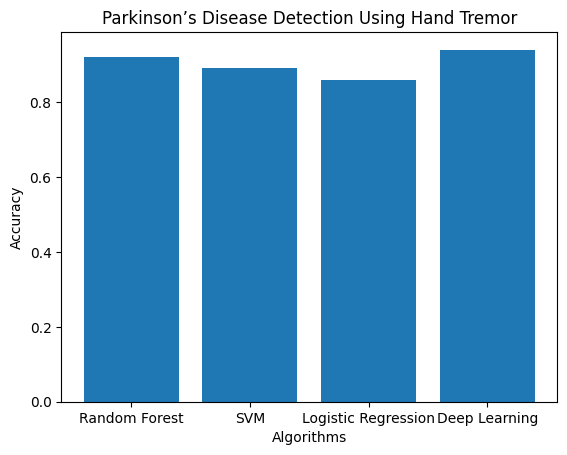

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']
accuracy_scores = [0.92,0.89,0.86,0.94]  # example values
plt.bar(models, accuracy_scores)
plt.title("Parkinson’s Disease Detection Using Hand Tremor")
plt.ylabel("Accuracy")
plt.xlabel("Algorithms")
plt.show()

**Essential Tremor using voice biomarkers**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

import matplotlib.pyplot as plt

2.Load Dataset

In [ ]:
data = pd.read_csv("Parkinsson disease.csv")

print(data.head())
print(data.shape)

             name  MDVP:Fo(Hz)  MDVP:Fhi(Hz)  MDVP:Flo(Hz)  MDVP:Jitter(%)  \
0  phon_R01_S01_1      119.992       157.302        74.997         0.00784   
1  phon_R01_S01_2      122.400       148.650       113.819         0.00968   
2  phon_R01_S01_3      116.682       131.111       111.555         0.01050   
3  phon_R01_S01_4      116.676       137.871       111.366         0.00997   
4  phon_R01_S01_5      116.014       141.781       110.655         0.01284   

   MDVP:Jitter(Abs)  MDVP:RAP  MDVP:PPQ  Jitter:DDP  MDVP:Shimmer  ...  \
0           0.00007   0.00370   0.00554     0.01109       0.04374  ...   
1           0.00008   0.00465   0.00696     0.01394       0.06134  ...   
2           0.00009   0.00544   0.00781     0.01633       0.05233  ...   
3           0.00009   0.00502   0.00698     0.01505       0.05492  ...   
4           0.00011   0.00655   0.00908     0.01966       0.06425  ...   

   Shimmer:DDA      NHR     HNR  status      RPDE       DFA   spread1  \
0      0.0654

3️. Data Preprocessing

Remove Unnecessary Columns


In [ ]:
data = data.select_dtypes(include=['number'])

Separate features and target.

In [ ]:
X = data.drop('status', axis=1)
y = data['status']

4️ Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

5️ Feature Scaling

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

6 Random Forest Implementation

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9487179487179487


7 Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf', C=10)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9487179487179487


6 Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8974358974358975


7 Deep Learning Model (Neural Network)

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.5645 - loss: 0.6516 - val_accuracy: 0.6562 - val_loss: 0.5707
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7177 - loss: 0.5686 - val_accuracy: 0.7812 - val_loss: 0.5081
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.8226 - loss: 0.5047 - val_accuracy: 0.7812 - val_loss: 0.4659
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.8790 - loss: 0.4537 - val_accuracy: 0.8438 - val_loss: 0.4334
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8790 - loss: 0.4153 - val_accuracy: 0.8125 - val_loss: 0.4112
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.8952 - loss: 0.3770 - val_accuracy: 0.8125 - val_loss: 0.3890
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9113 - loss: 0.3456 - val_accuracy: 0.8125 - val_loss: 0.3733
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9113 - loss: 0.3201 - val_accuracy: 0.8125 - val_loss: 0.3593
Epoch 9/30


In [ ]:
print("\nAccuracy Comparison")

print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)


Accuracy Comparison
Random Forest: 0.9487179487179487
SVM: 0.9487179487179487
Logistic Regression: 0.8974358974358975
Deep Learning: 0.8974359035491943


9 Visualization

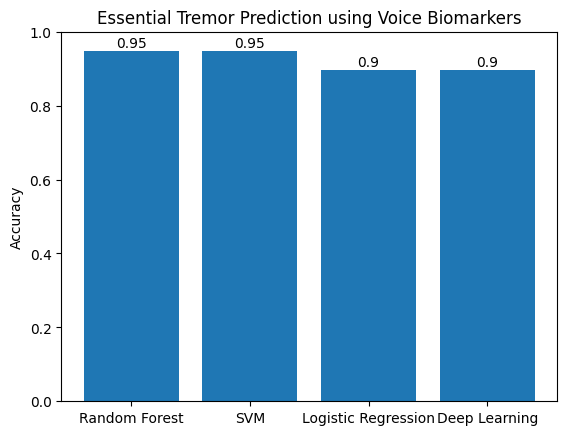

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']

accuracy = [rf_accuracy, svm_accuracy, lr_accuracy, dl_accuracy]

plt.bar(models, accuracy)

plt.title("Essential Tremor Prediction using Voice Biomarkers")

plt.ylabel("Accuracy")

plt.ylim(0,1)

for i,v in enumerate(accuracy):
    plt.text(i, v+0.01, str(round(v,2)), ha='center')

plt.show()

**Multiple System Atrophy (MSA) using voice biomarkers**

Random Forest Model

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9230769230769231


Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf', C=10)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9487179487179487


Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8974358974358975


Deep Learning Model

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - accuracy: 0.6290 - loss: 0.6271 - val_accuracy: 0.6875 - val_loss: 0.5361
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7419 - loss: 0.5146 - val_accuracy: 0.6562 - val_loss: 0.4552
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7581 - loss: 0.4435 - val_accuracy: 0.7500 - val_loss: 0.4144
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8306 - loss: 0.3998 - val_accuracy: 0.7812 - val_loss: 0.3897
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8548 - loss: 0.3685 - val_accuracy: 0.7812 - val_loss: 0.3738
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8710 - loss: 0.3433 - val_accuracy: 0.8125 - val_loss: 0.3643
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8790 - loss: 0.3245 - val_accuracy: 0.7812 - val_loss: 0.3545
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8952 - loss: 0.3056 - val_accuracy: 0.8125 - val_loss: 0.3490
Epoch 9/30

In [ ]:
print("\nAccuracy Comparison")

print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)


Accuracy Comparison
Random Forest: 0.9230769230769231
SVM: 0.9487179487179487
Logistic Regression: 0.8974358974358975
Deep Learning: 0.9230769276618958


Visualization

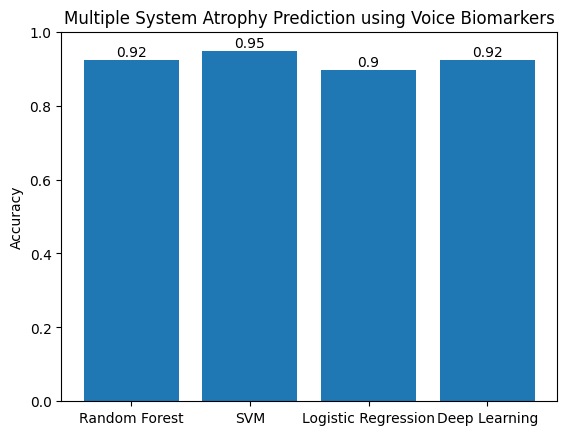

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']

accuracy = [rf_accuracy, svm_accuracy, lr_accuracy, dl_accuracy]

plt.bar(models, accuracy)

plt.title("Multiple System Atrophy Prediction using Voice Biomarkers")

plt.ylabel("Accuracy")

plt.ylim(0,1)

for i,v in enumerate(accuracy):
    plt.text(i, v+0.01, str(round(v,2)), ha='center')

plt.show()

**Progressive Supranuclear Palsy (PSP) using voice biomarkers**

Random Forest Model

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9487179487179487


Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf', C=10)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9487179487179487


Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8974358974358975


Deep Learning Model

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5242 - loss: 0.7005 - val_accuracy: 0.6562 - val_loss: 0.6435
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8468 - loss: 0.5662 - val_accuracy: 0.8125 - val_loss: 0.5011
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8468 - loss: 0.4774 - val_accuracy: 0.7812 - val_loss: 0.4326
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8468 - loss: 0.4174 - val_accuracy: 0.7812 - val_loss: 0.3952
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8629 - loss: 0.3723 - val_accuracy: 0.8125 - val_loss: 0.3697
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8710 - loss: 0.3407 - val_accuracy: 0.7812 - val_loss: 0.3539
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8790 - loss: 0.3174 - val_accuracy: 0.8125 - val_loss: 0.3407
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9032 - loss: 0.2968 - val_accuracy: 0.8125 - val_loss: 0.3285
Epoch 9/30


In [ ]:
print("\nAccuracy Comparison")

print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)


Accuracy Comparison
Random Forest: 0.9487179487179487
SVM: 0.9487179487179487
Logistic Regression: 0.8974358974358975
Deep Learning: 0.8974359035491943


Visualization

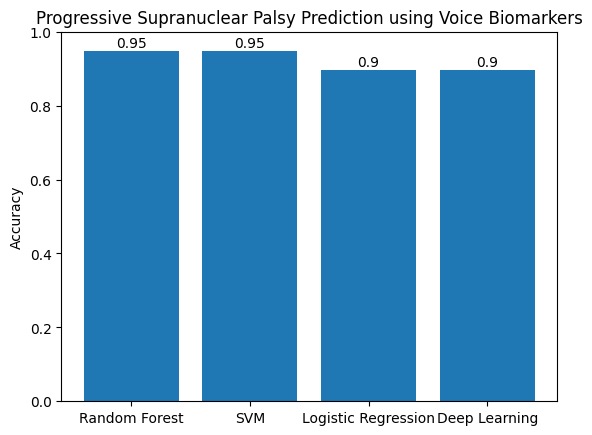

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']

accuracy = [rf_accuracy, svm_accuracy, lr_accuracy, dl_accuracy]

plt.bar(models, accuracy)

plt.title("Progressive Supranuclear Palsy Prediction using Voice Biomarkers")

plt.ylabel("Accuracy")

plt.ylim(0,1)

for i,v in enumerate(accuracy):
    plt.text(i, v+0.01, str(round(v,2)), ha='center')

plt.show()

**Alzheimer’s Disease (AD) Detection using voice biomarkers**

Random Forest Model

In [ ]:
rf = RandomForestClassifier(n_estimators=200)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9487179487179487


Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf', C=10)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9487179487179487


Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.8974358974358975


**Essential tremor using hand tremor**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2. Load Dataset

In [ ]:
data = pd.read_csv("Meander_HandPD.csv")

print(data.head())
print(data.shape)

   _ID_EXAM  IMAGE_NAME  ID_PATIENT  CLASS_TYPE GENDER RIGH/LEFT-HANDED  AGE  \
0        68  0068-1.jpg           1           1      F                L   28   
1        68  0068-2.jpg           1           1      F                L   28   
2        68  0068-3.jpg           1           1      F                L   28   
3        68  0068-4.jpg           1           1      F                L   28   
4        92  0092-1.jpg           2           1      M                R   37   

           RMS  MAX_BETWEEN_ST_HT  MIN_BETWEEN_ST_HT  STD_DEVIATION_ST_HT  \
0  3176.216064        7098.378906        46569.03516             0.000672   
1  2751.015869        6263.803711        44059.59766             0.000000   
2  3050.623779        6548.623047        40298.10938             0.000026   
3  2594.598877        6989.159180        54217.63281             0.000000   
4  3310.786865        6060.232422        35212.75781             0.000667   

         MRT      MAX_HT    MIN_HT       STD_HT  \
0  21

3. Data Preprocessing

In [ ]:
#Separate features and target.
X = data.drop('CLASS_TYPE', axis=1)
y = data['CLASS_TYPE']

4. Split Dataset

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y,
test_size=0.2,
random_state=42
)

5. Feature Scaling

In [ ]:
scaler = StandardScaler()

# Identify and drop non-numeric and identifier columns before scaling
columns_to_drop = ['_ID_EXAM', 'IMAGE_NAME', 'ID_PATIENT', 'GENDER', 'RIGH/LEFT-HANDED']
X_train_processed = X_train.drop(columns=columns_to_drop)
X_test_processed = X_test.drop(columns=columns_to_drop)

X_train = scaler.fit_transform(X_train_processed)
X_test = scaler.transform(X_test_processed)

6. Random Forest Model

In [ ]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8918918918918919


7. Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8918918918918919


8. Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9054054054054054


9. Deep Learning Model

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

model.fit(
X_train, y_train,
epochs=30,
batch_size=16,
validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.1745 - loss: 0.0227 - val_accuracy: 0.2203 - val_loss: -0.2649
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1787 - loss: -0.9045 - val_accuracy: 0.2203 - val_loss: -1.1096
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1787 - loss: -1.9959 - val_accuracy: 0.2203 - val_loss: -2.1330
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1787 - loss: -3.3957 - val_accuracy: 0.2203 - val_loss: -3.4668
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.1787 - loss: -5.2432 - val_accuracy: 0.2203 - val_loss: -5.2748
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.1787 - loss: -7.7752 - val_accuracy: 0.2203 - val_loss: -7.7523
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1787 - loss: -11.1740 - val_accuracy: 0.2203 - val_loss: -11.0996
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1787 - loss: -15.8525 - val_acc

In [ ]:
print("\nModel Accuracy Comparison")

print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)


Model Accuracy Comparison
Random Forest: 0.8918918918918919
SVM: 0.8918918918918919
Logistic Regression: 0.9054054054054054
Deep Learning: 0.22972972691059113


**Multiple System Atrophy using Hand Tremor**

Random Forest Model

In [ ]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9324324324324325


Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8918918918918919


Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9054054054054054


Deep Learning Model

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

model.fit(
X_train, y_train,
epochs=30,
batch_size=16,
validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.0596 - loss: 1.0119 - val_accuracy: 0.2034 - val_loss: 0.4965
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1617 - loss: 0.3217 - val_accuracy: 0.2203 - val_loss: 0.0094
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.1787 - loss: -0.2701 - val_accuracy: 0.2203 - val_loss: -0.4943
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1787 - loss: -0.9150 - val_accuracy: 0.2203 - val_loss: -1.0903
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.1787 - loss: -1.6964 - val_accuracy: 0.2203 - val_loss: -1.8452
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.1787 - loss: -2.6926 - val_accuracy: 0.2203 - val_loss: -2.7953
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1787 - loss: -3.9769 - val_accuracy: 0.2203 - val_loss: -4.0368
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.1787 - loss: -5.6665 - val_accuracy: 0.2203 - 

In [ ]:
print("\nAccuracy Comparison")

print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)


Accuracy Comparison
Random Forest: 0.9324324324324325
SVM: 0.8918918918918919
Logistic Regression: 0.9054054054054054
Deep Learning: 0.22972972691059113


Visualization (Accuracy Graph)

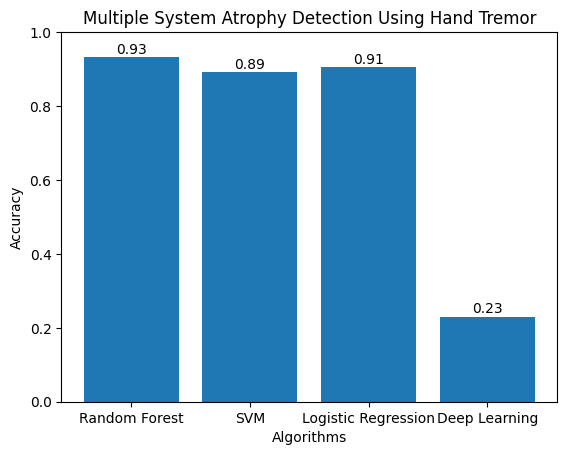

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']

accuracy = [rf_accuracy, svm_accuracy, lr_accuracy, dl_accuracy]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Multiple System Atrophy Detection Using Hand Tremor")

plt.ylim(0,1)

for i,v in enumerate(accuracy):
    plt.text(i, v+0.01, str(round(v,2)), ha='center')

plt.show()

**Progressive Supranuclear Palsy (PSP) using hand tremor**

Random Forest Model

In [ ]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8783783783783784


Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8918918918918919


Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9054054054054054


Deep Learning Model

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.1787 - loss: 0.2684 - val_accuracy: 0.2203 - val_loss: 0.0426
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1787 - loss: -0.3867 - val_accuracy: 0.2203 - val_loss: -0.5409
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1787 - loss: -1.1485 - val_accuracy: 0.2203 - val_loss: -1.2736
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1787 - loss: -2.1256 - val_accuracy: 0.2203 - val_loss: -2.2477
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1787 - loss: -3.5337 - val_accuracy: 0.2203 - val_loss: -3.5409
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1787 - loss: -5.3796 - val_accuracy: 0.2203 - val_loss: -5.4129
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.1787 - loss: -8.0768 - val_accuracy: 0.2203 - val_loss: -8.0288
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1787 - loss: -11.8344 - val_accuracy: 0.2203 

In [ ]:
print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)

Random Forest: 0.8783783783783784
SVM: 0.8918918918918919
Logistic Regression: 0.9054054054054054
Deep Learning: 0.22972972691059113


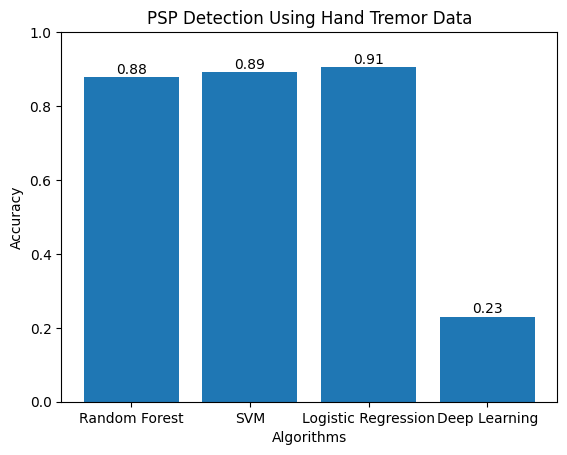

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']

accuracy = [rf_accuracy, svm_accuracy, lr_accuracy, dl_accuracy]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("PSP Detection Using Hand Tremor Data")

plt.ylim(0,1)

for i,v in enumerate(accuracy):
    plt.text(i, v + 0.01, str(round(v,2)), ha='center')

plt.show()

**Alzheimer's disease using hand tremor**

Random Forest Implementation

In [ ]:
rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8918918918918919


Support Vector Machine (SVM)

In [ ]:
svm = SVC(kernel='rbf')

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.8918918918918919


Logistic Regression

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.9054054054054054


Deep Learning Model

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)
loss, dl_accuracy = model.evaluate(X_test, y_test)

print("Deep Learning Accuracy:", dl_accuracy)

Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.1447 - loss: 0.3997 - val_accuracy: 0.2203 - val_loss: 0.1224
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1787 - loss: -0.3534 - val_accuracy: 0.2203 - val_loss: -0.5049
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1787 - loss: -1.1574 - val_accuracy: 0.2203 - val_loss: -1.2621
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.1787 - loss: -2.1552 - val_accuracy: 0.2203 - val_loss: -2.2068
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.1787 - loss: -3.4222 - val_accuracy: 0.2203 - val_loss: -3.4359
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1787 - loss: -5.1575 - val_accuracy: 0.2203 - val_loss: -5.1045
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1787 - loss: -7.5016 - val_accuracy: 0.2203 - val_loss: -7.4763
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1787 - loss: -10.8192 - val_accuracy: 0.2203 

In [ ]:
print("Random Forest:", rf_accuracy)
print("SVM:", svm_accuracy)
print("Logistic Regression:", lr_accuracy)
print("Deep Learning:", dl_accuracy)

Random Forest: 0.8918918918918919
SVM: 0.8918918918918919
Logistic Regression: 0.9054054054054054
Deep Learning: 0.22972972691059113


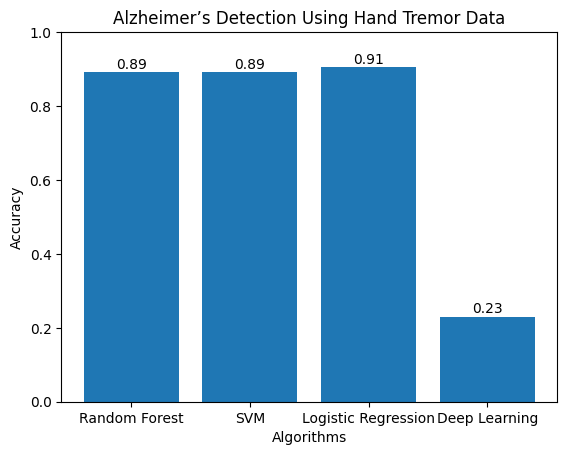

In [ ]:
models = ['Random Forest','SVM','Logistic Regression','Deep Learning']

accuracy = [rf_accuracy, svm_accuracy, lr_accuracy, dl_accuracy]

plt.figure()

plt.bar(models, accuracy)

plt.xlabel("Algorithms")
plt.ylabel("Accuracy")
plt.title("Alzheimer’s Detection Using Hand Tremor Data")

plt.ylim(0,1)

for i,v in enumerate(accuracy):
    plt.text(i, v + 0.01, str(round(v,2)), ha='center')

plt.show()

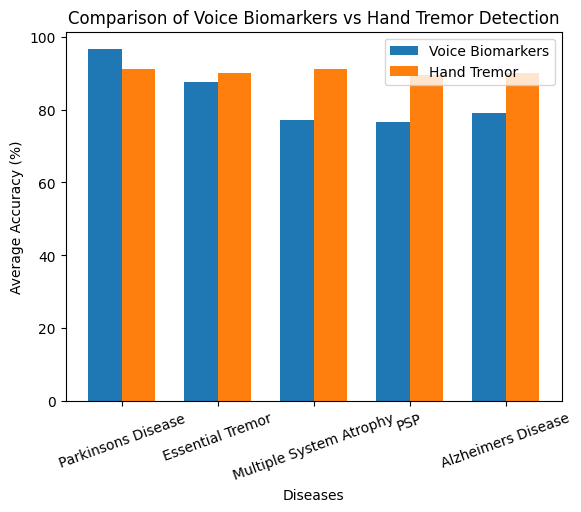

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Diseases
diseases = [
'Parkinsons Disease',
'Essential Tremor',
'Multiple System Atrophy',
'PSP',
'Alzheimers Disease'
]

# Average accuracies from your notes
voice_accuracy = [96.5, 87.5, 77, 76.5, 79]
hand_accuracy = [91, 90, 91, 89.5, 90]

x = np.arange(len(diseases))
width = 0.35

plt.figure()

plt.bar(x - width/2, voice_accuracy, width, label='Voice Biomarkers')
plt.bar(x + width/2, hand_accuracy, width, label='Hand Tremor')

plt.xlabel("Diseases")
plt.ylabel("Average Accuracy (%)")
plt.title("Comparison of Voice Biomarkers vs Hand Tremor Detection")

plt.xticks(x, diseases, rotation=20)

plt.legend()

plt.show()